## Idea
I want to build a shortest path analysis of routes people would take from their home to work (the subway) in Grasshopper. The datasets I am going to use are the subway station locations from the MTA, street centerlines from NYC Open Data and building census according to tax lots. The reason I ended up choosing centerlines and not OpenStreet Maps was because 
    A) I wasnt aware of the dataset initially, particularly the sidewalk paths that were included in the dataset. Good to know because I ended up doing a fun but circuitous option that you can explore here (/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/NYCPathways_1stTry.ipynb). The short story of this build was attempting to construct centerlines of park paths from the NYC Planimetric Database. Basically making a centerline from the middle of the polygon. It "worked" but when I uploaded to Grasshopper it ended up being a collection of a bunch of small lines, making the computational load very heavy.
    B) -and a big reason for not switching to the OpenStreet data once I learned about it was because I did not want the visualization to be too crowded in Grasshopper. My thought was, viewed from a neighborhood scale like Bed-Stuy individual paths on each side of a street would end up being visually confusing and miss the analysis. Maybe once particular "high intereaction streets" are identified I could point zoom into these sections and show if there is any nuance per street. 

Another obstacle I ran into was the files could not be too large in order for Grasshopper to run an analysis. This is something I'm learning and I'm curious on your take of at what scale does it make sense to switch frrom an analysis in Grasshopper to one using Python.

## Defining Boundaries

For all of the datasets I will be bounding the areas by neighborhood so I'm defining that now. I went ahead and pulled neighborhood tabulation areas dataset as some of the datasets did not have internal defining of neighborhoods, just geolocation.

In [42]:
import geopandas as gpd

WORKING_CRS = 4326  # main working CRS for this notebook

nta = gpd.read_file("/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/Data/2020_Neighborhood_Tabulation_Areas_(NTAs)_20260717.geojson").to_crs(WORKING_CRS)

neighborhoods = {
    "bedstuy": "Bedford-Stuyvesant",
    "jacksonheights": "Jackson Heights"
}

boundaries = {}
for key, name_filter in neighborhoods.items():  # the for and in pair are saying "within neighborhoods filter by the key and name_filter"
    parts = nta[nta["ntaname"].str.contains(name_filter, na=False)] #filtering out items that do not fit the filter
    print(f"{key}: {len(parts)} NTA piece(s) found") 
    boundaries[key] = gpd.GeoDataFrame(geometry=[parts.unary_union], crs=WORKING_CRS) #this part is creating a GeoDataFrame from the boundaries defined above.

bedstuy: 2 NTA piece(s) found
jacksonheights: 1 NTA piece(s) found


/var/folders/jm/2cq5x30j3gx977bqk1tjsk0r0000gn/T/ipykernel_62917/1005818331.py:16: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  boundaries[key] = gpd.GeoDataFrame(geometry=[parts.unary_union], crs=WORKING_CRS) #this part is creating a GeoDataFrame from the boundaries defined above.
/var/folders/jm/2cq5x30j3gx977bqk1tjsk0r0000gn/T/ipykernel_62917/1005818331.py:16: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  boundaries[key] = gpd.GeoDataFrame(geometry=[parts.unary_union], crs=WORKING_CRS) #this part is creating a GeoDataFrame from the boundaries defined above.


In [43]:
WALK_15MIN_FT = 3960  # 15 min walk
BUFFER_CRS = 2263      # feet-based CRS, needed for a real distance buffer

boundaries_ft = {key: b.to_crs(BUFFER_CRS) for key, b in boundaries.items()}    # reprojecting boundaries to feet, same pattern as before but applied to a different CRS

study_area_ft = gpd.GeoSeries(
    [b.geometry.iloc[0].buffer(WALK_15MIN_FT) for b in boundaries_ft.values()],  # adds a 15-min-walk buffer to each boundary in boundaries_ft
    crs=BUFFER_CRS #referring to CRS defined above. Need to do this because you need to tell the function what CRS to use.
).union_all()

study_area = gpd.GeoSeries([study_area_ft], crs=BUFFER_CRS).to_crs(WORKING_CRS).iloc[0]

## Subway Points
To start I am importing the subway MTA subway data and applying the boundry that I defined earlier to it-narrowing the focus. 

In [44]:
from shapely.validation import make_valid

IN_PATH = "/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/Data/MTA_Subway_Stations_20260723.geojson"

gdf = gpd.read_file(IN_PATH).to_crs(WORKING_CRS)
gdf = gdf[gdf.geometry.intersects(study_area)]  
gdf["geometry"] = gdf.geometry.apply(lambda g: make_valid(g) if g is not None else g)
gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty]

print(f"{len(gdf)} stations within the study area")

57 stations within the study area


In [45]:
import os

os.makedirs("outputs", exist_ok=True)
OUT_PATH = "outputs/subway_stops.geojson"

gdf.to_file(OUT_PATH, driver="GeoJSON")
print(f"Exported {len(gdf)} stations -> {OUT_PATH}")

Exported 57 stations -> outputs/subway_stops.geojson


## Centerline

Pretty much the same thing here. Except here I'm cutting up the data into Bed-Stuy, Jackson Heights and just a normal Centerline. Previously I had defined the bounds for each neighborhood. I am adding a mile to each in order to make sure there are not any weird cutoffs. 

In [46]:
IN_PATH = "/Users/temp/Documents/GitHub/cdp-mapping-systems/Personal Work/Pathmapping_Tool/Data/Centerline_20260723.geojson"  # confirm this matches the real filename via Copy Path before running

cl = gpd.read_file(IN_PATH).to_crs(BUFFER_CRS) #applying 15 min buffer previously defined.
cl = cl[cl.geometry.intersects(study_area_ft)] 

cl["geometry"] = cl.geometry.apply(lambda g: make_valid(g) if g is not None else g)
cl = cl[cl.geometry.notna() & ~cl.geometry.is_empty]

cl = cl.to_crs(WORKING_CRS)

print(f"{len(cl)} centerline segments within the 15-min walk buffer")

8014 centerline segments within the 15-min walk buffer


I used this data for a Grasshoppper analysis and it was critical that these datasets were in separate files in order reduce the study area

In [47]:
import os
os.makedirs("outputs", exist_ok=True)

cl.to_file("outputs/centerline.geojson", driver="GeoJSON")
print(f"combined: {len(cl)} segments -> outputs/centerline.geojson")

cl_ft = cl.to_crs(BUFFER_CRS) 

for key, out_path in [
    ("bedstuy", "outputs/centerline_bedstuy.geojson"),
    ("jacksonheights", "outputs/centerline_jacksonheights.geojson"),
]:
    neighborhood_buffer = boundaries_ft[key].geometry.iloc[0].buffer(WALK_15MIN_FT)
    clipped = cl_ft[cl_ft.geometry.intersects(neighborhood_buffer)].to_crs(WORKING_CRS)
    print(f"{key}: {len(clipped)} segments -> {out_path}")
    clipped.to_file(out_path, driver="GeoJSON")

combined: 8014 segments -> outputs/centerline.geojson
bedstuy: 4333 segments -> outputs/centerline_bedstuy.geojson
jacksonheights: 3681 segments -> outputs/centerline_jacksonheights.geojson


## Census by Taxlot

250 Census block groups within the study area


<Axes: >

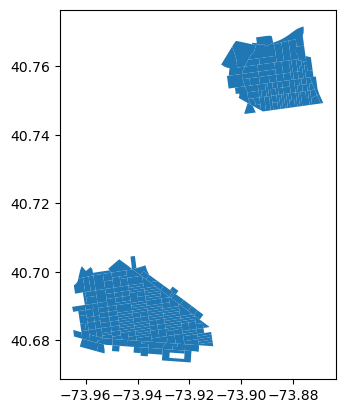

In [54]:
tight_area_native = gpd.GeoSeries([tight_area], crs=WORKING_CRS).to_crs(2263).iloc[0]

census_gdf = gpd.read_file(
    "/Users/temp/Documents/GitHub/cdp-mapping-systems/content/Data/census_nyc_sp.fgb",
    mask=tight_area_native
).to_crs(WORKING_CRS)

print(f"{len(census_gdf)} Census block groups within the study area")
census_gdf.plot()

250 Census block groups within the study area


<Axes: >

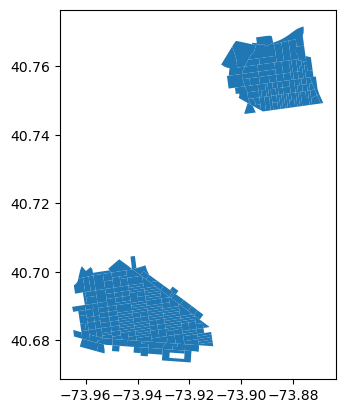

In [56]:
tight_area = gpd.GeoSeries(
    [b.geometry.iloc[0] for b in boundaries.values()], crs=WORKING_CRS
).union_all()

tight_area_native = gpd.GeoSeries([tight_area], crs=WORKING_CRS).to_crs(2263).iloc[0]

census_gdf = gpd.read_file(
    "/Users/temp/Documents/GitHub/cdp-mapping-systems/content/Data/census_nyc_sp.fgb",
    mask=tight_area_native
).to_crs(WORKING_CRS)

print(f"{len(census_gdf)} Census block groups within the study area")
census_gdf.plot()

In [57]:
import requests

#I am fetching the MapPluto data because its very large to import and is eaiser to fetch only the neighborhoods I need rather than filtering here.
def fetch_pluto_for_bounds(bounds, layer_wkid=WORKING_CRS):
    """Fetch MapPLUTO tax lots intersecting a bounding box (xmin, ymin, xmax, ymax)."""
    base_url = "https://services5.arcgis.com/GfwWNkhOj9bNBqoJ/arcgis/rest/services/MAPPLUTO/FeatureServer/0/query"
    xmin, ymin, xmax, ymax = bounds

    all_features, offset = [], 0
    while True:
        params = {
            "geometry": f"{xmin},{ymin},{xmax},{ymax}",
            "geometryType": "esriGeometryEnvelope",
            "inSR": layer_wkid,
            "spatialRel": "esriSpatialRelIntersects",
            "outFields": "CD,LandUse,UnitsRes,BCTCB2020,BCT2020",
            "returnGeometry": "true",
            "outSR": layer_wkid,
            "resultOffset": offset,
            "resultRecordCount": 2000,
            "f": "geojson",
        }
        r = requests.get(base_url, params=params)
        r.raise_for_status()
        fc = r.json()
        if "error" in fc:
            raise RuntimeError(fc["error"])
        feats = fc.get("features", [])
        all_features.extend(feats)
        if len(feats) < 2000:
            break
        offset += 2000

    return gpd.GeoDataFrame.from_features(all_features, crs=f"EPSG:{layer_wkid}")


pluto_gdfs = {}
for key, boundary in boundaries.items():
    pluto_gdfs[key] = fetch_pluto_for_bounds(boundary.total_bounds)
    print(f"{key}: {len(pluto_gdfs[key])} tax lots fetched")

bedstuy: 22464 tax lots fetched
jacksonheights: 10711 tax lots fetched


23345 total tax lots across both neighborhoods


<Axes: >

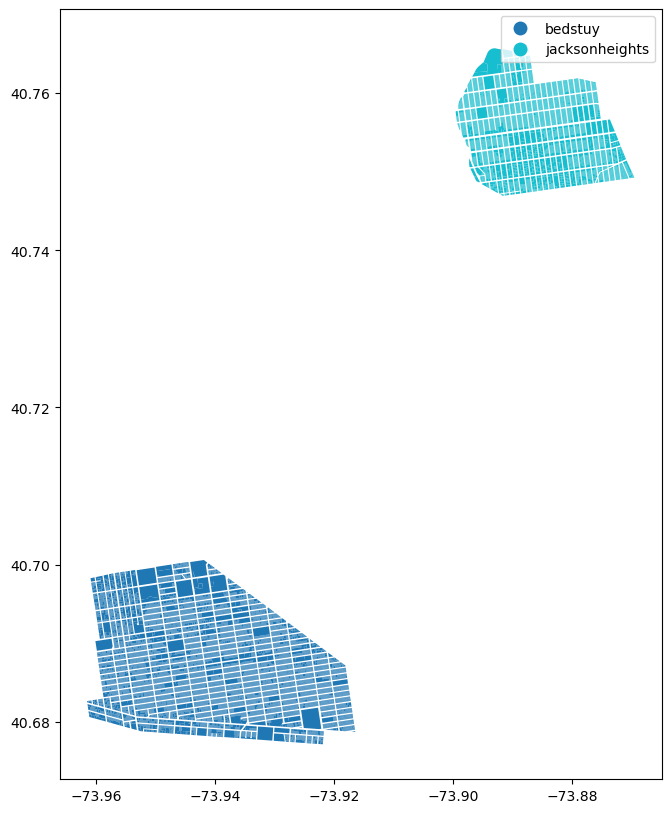

In [58]:
import pandas as pd

clipped = []
for key, gdf in pluto_gdfs.items():
    lots = gpd.clip(gdf, boundaries[key])
    lots["neighborhood"] = key
    clipped.append(lots)

pluto_gdf = pd.concat(clipped, ignore_index=True)
pluto_gdf = gpd.GeoDataFrame(pluto_gdf, crs=WORKING_CRS)

print(f"{len(pluto_gdf)} total tax lots across both neighborhoods")
pluto_gdf.plot(column="neighborhood", legend=True, figsize=(10, 10))

In [59]:
pluto_gdf["block_group"] = pluto_gdf["BCTCB2020"].str[1:8]
census_gdf["block_group"] = census_gdf["GISJOIN"].str[8:]

def apportion_population_to_tax_lot(row, pluto_gdf, census_gdf):
    """Apportion population in a census block group to tax lots based on residential units."""
    block_group = row["block_group"]
    if block_group not in census_gdf["block_group"].values:
        return 0
    population = census_gdf[census_gdf["block_group"] == block_group][
        "Total Pop (Race/Ethnicity)"
    ].values[0]
    pluto_subset = pluto_gdf[pluto_gdf["block_group"] == block_group]
    total_units = pluto_subset["UnitsRes"].sum()
    if total_units == 0:
        return 0
    return row["UnitsRes"] / total_units * population


pluto_gdf["est_pop_per_lot"] = pluto_gdf.apply(
    lambda row: apportion_population_to_tax_lot(row, pluto_gdf, census_gdf), axis=1
)

pluto_gdf.groupby("neighborhood")["est_pop_per_lot"].sum()

neighborhood
bedstuy           168572.099078
jacksonheights     70887.900922
Name: est_pop_per_lot, dtype: float64

In [60]:
import os
os.makedirs("outputs", exist_ok=True)

pluto_gdf.to_file("outputs/population_by_taxlot.geojson", driver="GeoJSON")
print(f"combined: {len(pluto_gdf)} tax lots -> outputs/population_by_taxlot.geojson")

for key in neighborhoods:
    subset = pluto_gdf[pluto_gdf["neighborhood"] == key]
    out_path = f"outputs/population_by_taxlot_{key}.geojson"
    subset.to_file(out_path, driver="GeoJSON")
    print(f"{key}: {len(subset)} tax lots -> {out_path}")

combined: 23345 tax lots -> outputs/population_by_taxlot.geojson
bedstuy: 16597 tax lots -> outputs/population_by_taxlot_bedstuy.geojson
jacksonheights: 6748 tax lots -> outputs/population_by_taxlot_jacksonheights.geojson
